# Hotel Harmony - Booking Data EDA

## 1. Load & Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("hotel_bookings.csv")

# agent/company: NULL means "not applicable" (e.g. no agent used), not missing data
df["agent"] = df["agent"].replace("NULL", np.nan)
df["company"] = df["company"].replace("NULL", np.nan)

# children: a few true missing values, fill with 0 (reasonable default)
df["children"] = df["children"].fillna(0)

df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], errors="coerce")

df = df.drop_duplicates()

print("Clean shape:", df.shape)

Clean shape: (87396, 32)


## 2. Basic Questions

**Average lead time (days)**

In [2]:
df["lead_time"].mean().round(2)

np.float64(79.89)

**Bookings canceled**

In [3]:
df["is_canceled"].sum()

np.int64(24025)

**Most common arrival month**

In [4]:
df["arrival_date_month"].mode()[0]

'August'

**Avg special requests per booking**

In [5]:
df["total_of_special_requests"].mean().round(2)

np.float64(0.7)

**Country with most bookings**

In [6]:
df["country"].value_counts().idxmax()

'PRT'

**Avg ADR by hotel type**

In [7]:
df.groupby("hotel")["adr"].mean().round(2)

hotel
City Hotel      110.99
Resort Hotel     99.03
Name: adr, dtype: float64

**% of guests requiring parking**

In [8]:
(df["required_car_parking_spaces"] > 0).mean() * 100

np.float64(8.367659847132591)

**Avg stay duration (week/weekend nights)**

In [9]:
df[["stays_in_week_nights", "stays_in_weekend_nights"]].mean().round(2)

stays_in_week_nights       2.63
stays_in_weekend_nights    1.01
dtype: float64

**Bookings made through travel agents**

In [10]:
df["agent"].notna().sum()

np.int64(75203)

**Distribution of bookings by hotel type**

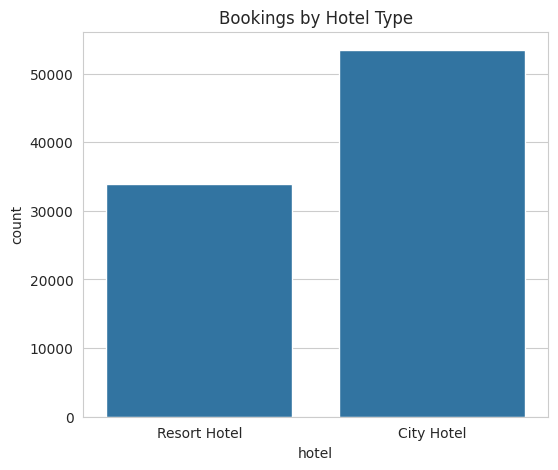

In [11]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="hotel")
plt.title("Bookings by Hotel Type")
plt.show()

## 3. Medium Questions

**Cancellation rate by hotel type**

In [12]:
df.groupby("hotel")["is_canceled"].mean().round(3)

hotel
City Hotel      0.300
Resort Hotel    0.235
Name: is_canceled, dtype: float64

**Avg ADR per market segment**

In [13]:
df.groupby("market_segment")["adr"].mean().sort_values(ascending=False).round(2)

market_segment
Online TA        118.17
Direct           116.58
Aviation         100.17
Offline TA/TO     81.76
Groups            74.86
Corporate         68.15
Undefined         15.00
Complementary      3.05
Name: adr, dtype: float64

**Distribution channel with most bookings**

In [14]:
df["distribution_channel"].value_counts().idxmax()

'TA/TO'

**Avg previous cancellations by hotel type**

In [15]:
df.groupby("hotel")["previous_cancellations"].mean().round(3)

hotel
City Hotel      0.036
Resort Hotel    0.022
Name: previous_cancellations, dtype: float64

**Month with highest total ADR (revenue proxy)**

In [16]:
df.groupby("arrival_date_month")["adr"].sum().sort_values(ascending=False).head(5)

arrival_date_month
August    1698412.48
July      1363146.03
June       929859.68
May        929040.10
April      819368.35
Name: adr, dtype: float64

**Avg stay duration: repeat vs new guests**

In [17]:
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]
df.groupby("is_repeated_guest")["total_nights"].mean().round(2)

is_repeated_guest
0    3.70
1    1.93
Name: total_nights, dtype: float64

**Room type with most bookings**

In [18]:
df["reserved_room_type"].value_counts().head(5)

reserved_room_type
A    56552
D    17398
E     6049
F     2823
G     2052
Name: count, dtype: int64

**Lead time vs cancellation (scatter)**

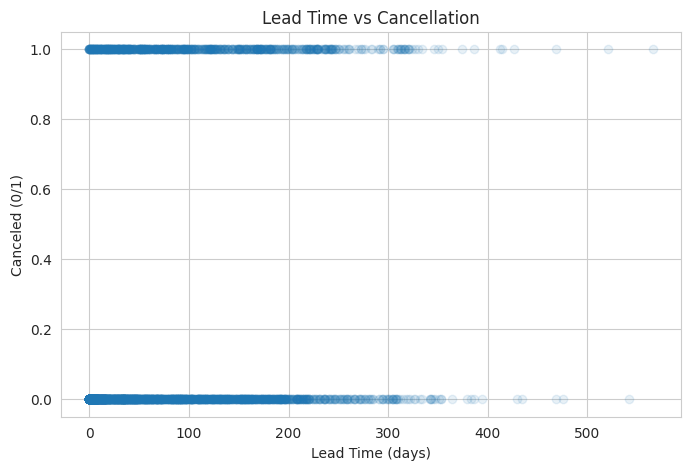

In [19]:
plt.figure(figsize=(8, 5))
sample = df.sample(3000, random_state=1)
plt.scatter(sample["lead_time"], sample["is_canceled"], alpha=0.1)
plt.xlabel("Lead Time (days)")
plt.ylabel("Canceled (0/1)")
plt.title("Lead Time vs Cancellation")
plt.show()

**ADR trend over the years**

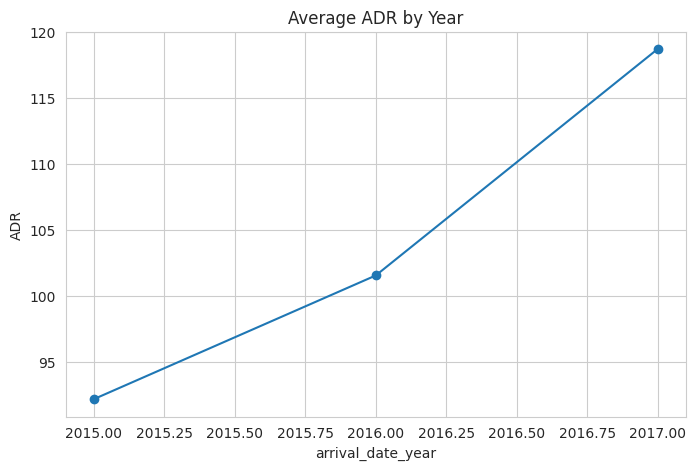

In [20]:
yearly_adr = df.groupby("arrival_date_year")["adr"].mean()
plt.figure(figsize=(8, 5))
yearly_adr.plot(marker="o")
plt.title("Average ADR by Year")
plt.ylabel("ADR")
plt.show()

**Special requests vs ADR**

In [21]:
df.groupby("total_of_special_requests")["adr"].mean().round(2)

total_of_special_requests
0     99.67
1    109.65
2    118.57
3    125.07
4    131.09
5    129.98
Name: adr, dtype: float64

## 4. Advanced Questions

*Advanced Q1 (cancellation drivers via logistic regression) and Q2 (ADR vs guest composition via multiple regression) are dropped — out of scope for pandas/numpy/matplotlib only.*

**Booking changes vs special requests (correlation)**

In [22]:
corr = df["booking_changes"].corr(df["total_of_special_requests"])
corr.round(3)

np.float64(0.016)

**Cancellation rate by month (seasonal pattern)**

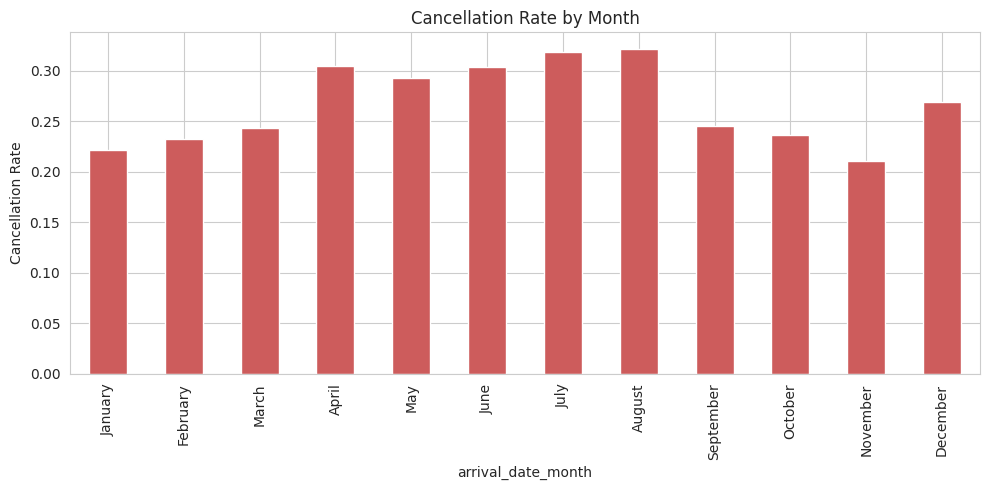

In [23]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
seasonal_cancel = df.groupby("arrival_date_month")["is_canceled"].mean().reindex(month_order)
plt.figure(figsize=(10, 5))
seasonal_cancel.plot(kind="bar", color="indianred")
plt.title("Cancellation Rate by Month")
plt.ylabel("Cancellation Rate")
plt.tight_layout()
plt.show()

**Lead time distribution by market segment**

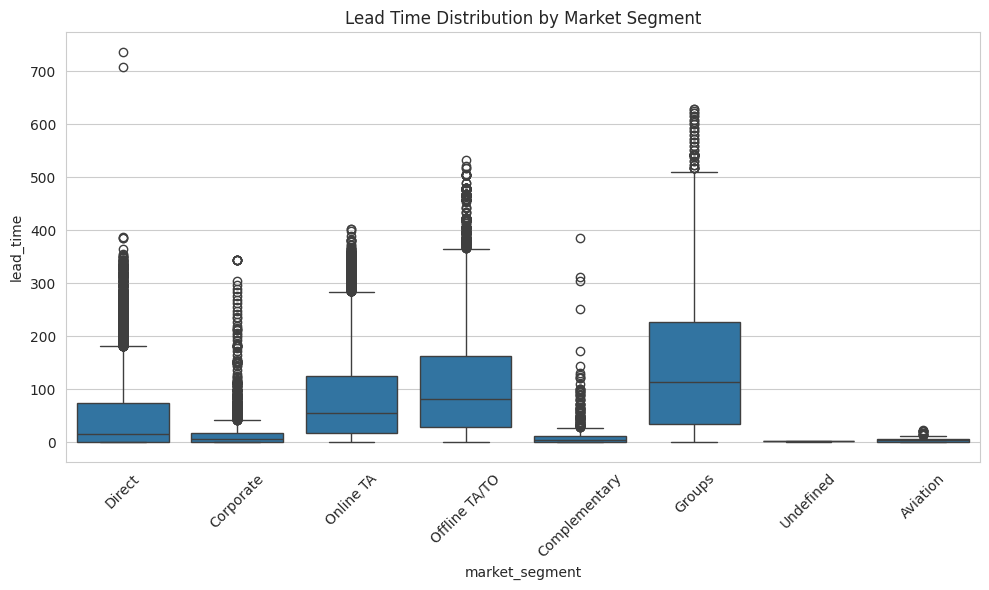

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="market_segment", y="lead_time")
plt.xticks(rotation=45)
plt.title("Lead Time Distribution by Market Segment")
plt.tight_layout()
plt.show()